In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [5]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

In [9]:
print(" training images shape:", X_train.shape)
print("training labels shape:", Y_train.shape)

 training images shape: (60000, 28, 28)
training labels shape: (60000,)


In [11]:
Y_train[7]

np.uint8(3)

Text(0.5, 1.0, 'Label : 3')

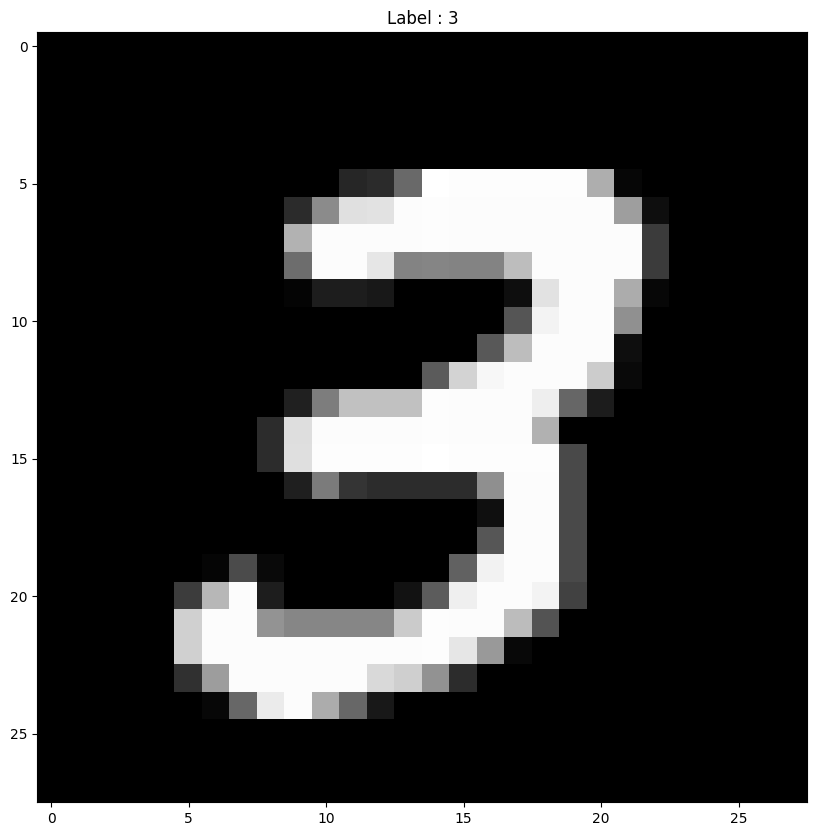

In [31]:
plt.figure(figsize = (10,10))
plt.imshow(X_train[7], cmap = 'grey')
plt.title(f"Label : {str(Y_train[7])}")

In [40]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [44]:
X_train.shape
X_test.shape

(10000, 28, 28, 1)

In [50]:
X_train_norm = (X_train - X_train.min()) / (X_train.max() - X_train.min())
X_test_norm = (X_test - X_test.min()) / (X_test.max() - X_test.min())

In [52]:
Y_train = tf.keras.utils.to_categorical(Y_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_test, 10)

In [68]:
model = Sequential([
    
    Conv2D(32, (3, 3), activation ='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),

    Flatten(),
    
    Dense(128, activation='relu'),
    
    Dropout(0.5),

    Dense(10, activation='softmax')

])

In [71]:
model.compile(
    optimizer = 'adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size = 64,
    validation_split=0.1,
    verbose =1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 98s 103ms/step - accuracy: 0.8984 - loss: 0.4364 - val_accuracy: 0.9842 - val_loss: 0.0546
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 140s 101ms/step - accuracy: 0.9687 - loss: 0.1079 - val_accuracy: 0.9848 - val_loss: 0.0516
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 139s 97ms/step - accuracy: 0.9790 - loss: 0.0735 - val_accuracy: 0.9895 - val_loss: 0.0490
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - accuracy: 0.9826 - loss: 0.0615 - val_accuracy: 0.9888 - val_loss: 0.0417
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 149s 106ms/step - accuracy: 0.9846 - loss: 0.0527 - val_accuracy: 0.9887 - val_loss: 0.0443
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 86s 102ms/step - accuracy: 0.9862 - loss: 0.0492 - val_accuracy: 0.9895 - val_loss: 0.0412
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 148s 109ms/step - accuracy: 0.9881 - loss: 0.0417 - val_accuracy: 0.9912 - val_loss: 0.0393
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 128s 92ms/step - accuracy: 0.9887 - loss:

In [75]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


In [83]:
prediction[67].shape

(10,)

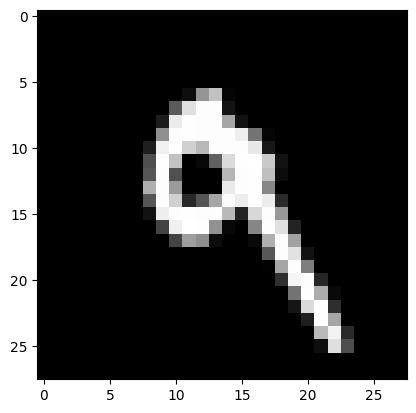

In [85]:
plt.imshow(X_test[7].reshape(28, 28), cmap= 'grey')

In [89]:
Y_test[7]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

the predicted number is 7
the predicted number is 2
the predicted number is 1
the predicted number is 0
the predicted number is 4


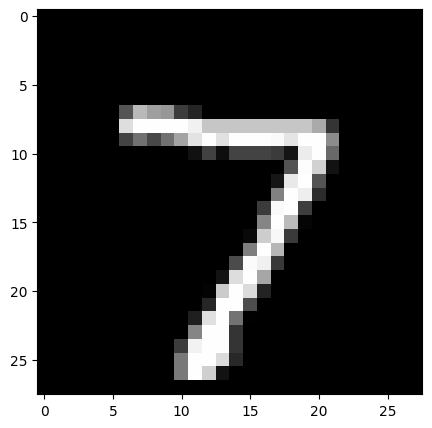

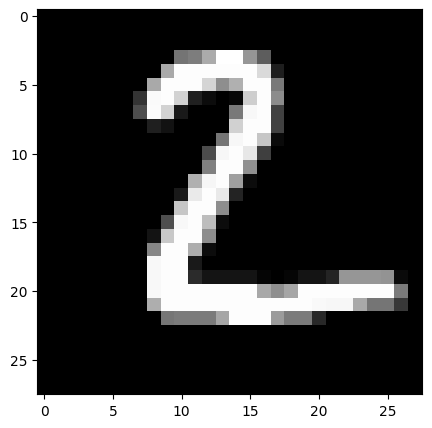

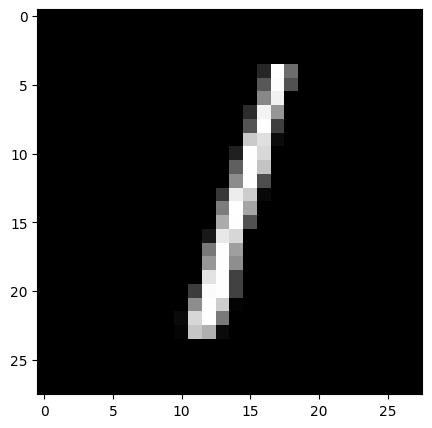

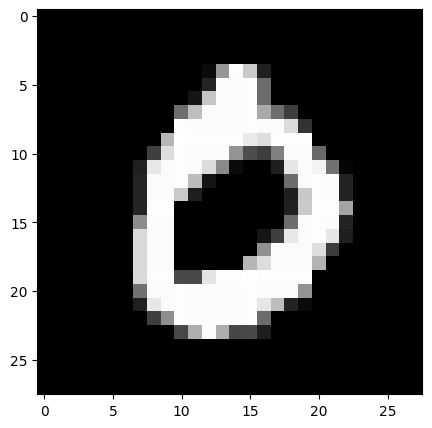

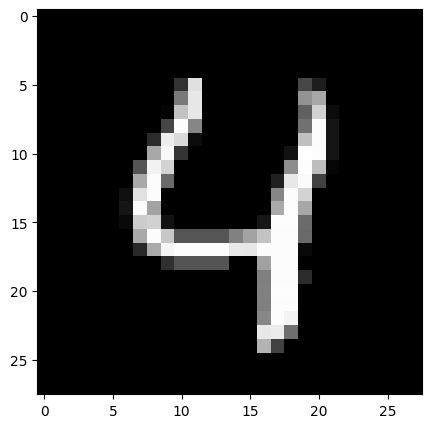

In [97]:
for i in range(5):
    index = Y_test[i]
    plt.figure(figsize=(5, 5))
    plt.imshow(X_test[i].reshape(28, 28), cmap='grey')
    print(f"the predicted number is {np.argmax(index)}")

In [103]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [115]:
Y_pred = np.argmax(prediction, axis=1)
Y_true = np.argmax(Y_test, axis=1)

In [117]:
Y_true.shape

(10000,)

In [119]:
cf_matrix = confusion_matrix(Y_true, Y_pred)

In [121]:
cf_matrix

array([[ 977,    0,    0,    0,    0,    0,    2,    1,    0,    0],
       [   0, 1131,    0,    2,    0,    0,    1,    1,    0,    0],
       [   0,    0, 1025,    3,    0,    0,    1,    2,    0,    1],
       [   0,    0,    0, 1007,    0,    1,    0,    1,    1,    0],
       [   0,    1,    0,    0,  967,    0,    5,    0,    1,    8],
       [   1,    0,    0,   10,    0,  879,    0,    0,    1,    1],
       [   3,    2,    0,    0,    0,    0,  953,    0,    0,    0],
       [   0,    2,    3,    1,    1,    1,    0, 1020,    0,    0],
       [   1,    0,    3,    2,    1,    1,    0,    2,  960,    4],
       [   0,    1,    0,    2,    4,    1,    0,    2,    2,  997]])

In [125]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_true, Y_pred, target))